In [14]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

In [15]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper
from langchain_community.tools.tavily_search import TavilySearchResults

wiki_api = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500)
wiki_tool = WikipediaQueryRun(api_wrapper=wiki_api, description="Query Wikipedia for pickle ball sport info")

tavily_tool = TavilySearchResults()

tools = [wiki_tool, tavily_tool]

In [16]:
from PyPDF2 import PdfReader
from langchain.docstore.document import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain.tools.retriever import create_retriever_tool

# Load the PDF
def load_pdf(pdf_path):
    reader = PdfReader(pdf_path)
    text = ""
    for page in reader.pages:
        text += page.extract_text() or ""
    return [Document(page_content=text)]

pdf_path = "Pickleball-Rulebook.pdf"
docs = load_pdf(pdf_path)

# Split
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
chunks = splitter.split_documents(docs)

# Use free local embeddings
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

vectorstore = Chroma.from_documents(chunks, embedding=embeddings, persist_directory="./chroma_db")

pdf_retriever = vectorstore.as_retriever()

pdf_tool = create_retriever_tool(
    pdf_retriever,
    name="pickle_ball_rules_pdf",
    description="Answer questions about pickle ball rules from the official PDF guide."
)

tools = []
tools.append(pdf_tool)


In [17]:
from langchain_community.document_loaders import YoutubeLoader

yt_url = "https://www.youtube.com/watch?v=rD1O3R9B0Sw"

yt_loader = YoutubeLoader.from_youtube_url(
    yt_url,
    add_video_info=False,
    language=["en"]
)
yt_docs = yt_loader.load()

yt_chunks = splitter.split_documents(yt_docs)
vectorstore.add_documents(yt_chunks)

yt_retriever = vectorstore.as_retriever(search_kwargs={"k": 4})
yt_tool = create_retriever_tool(
    yt_retriever,
    name="pickle_ball_youtube",
    description="Answer pickle ball questions using YouTube video transcripts"
)
tools.append(yt_tool)


In [ ]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen-qwq-32b") #qwen2-72b-chat

llm_with_tools = llm.bind_tools(tools=tools)

# test the llm standalone
print(llm_with_tools.invoke("What is pickle ball?"))

content='' additional_kwargs={'reasoning_content': 'Okay, the user is asking, "What is pickle ball?" I need to figure out which tool to use here. The available tools are pickle_ball_rules_pdf and pickle_ball_youtube. \n\nFirst, the question is a general inquiry about what pickle ball is. The rules PDF function might provide the official rules or an overview, which would be helpful. Alternatively, a YouTube video could offer a visual explanation. Since the user is asking for a definition or introduction, maybe the rules PDF is more straightforward for a textual explanation. But sometimes videos are better for new concepts. Hmm, maybe both? Wait, but the user might just need a quick answer. Let me check the function descriptions again. The rules_pdf\'s query parameter is to look up in a retriever, so perhaps it can fetch a document about the rules. The YouTube function would search for videos. Since the question is general, maybe the best approach is to use both tools. But I can only cal

In [19]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


In [20]:
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile()

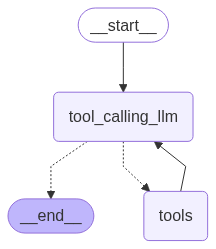

================================ Human Message =================================

Hi, please explain how pickle ball scoring works?
================================== Ai Message ==================================
Tool Calls:
  pickle_ball_rules_pdf (q12jfewzg)
 Call ID: q12jfewzg
  Args:
    query: pickle ball scoring rules
  pickle_ball_youtube (p9gy1gerz)
 Call ID: p9gy1gerz
  Args:
    query: how to score in pickleball explained
================================= Tool Message =================================
Name: pickle_ball_rules_pdf

the score is being called.  
4.M.10.  The server violates any of the rules listed in Rule 4.A.4.  
4.N. Receiver Faults. It is a fault against the receiving team 
resulting in a point for the server if:  
4.N.1.  The receiver or their partner is touched by or interferes with the flight of the ball before it bounces.  
4.N.2.  The receiver or their partner calls a time -out after 
the serve has occurred.    
 
 
 29 
USA PICKLEBALL OFFICIAL RULEBOOK (

In [22]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

# 7. Final test
messages = graph.invoke({
    "messages": "Hi, please explain how pickle ball scoring works?"
})
for m in messages['messages']:
    m.pretty_print()